Data loaded successfully.
Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        46043 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       46033 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   47985 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB

Missing values (count):
age        

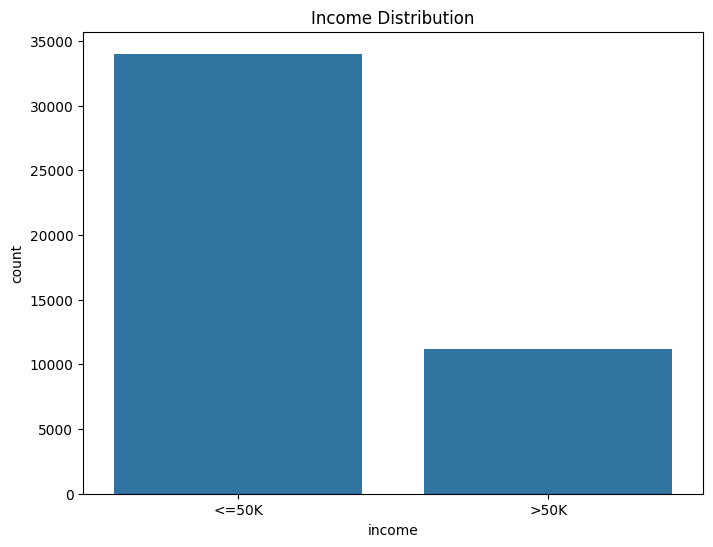

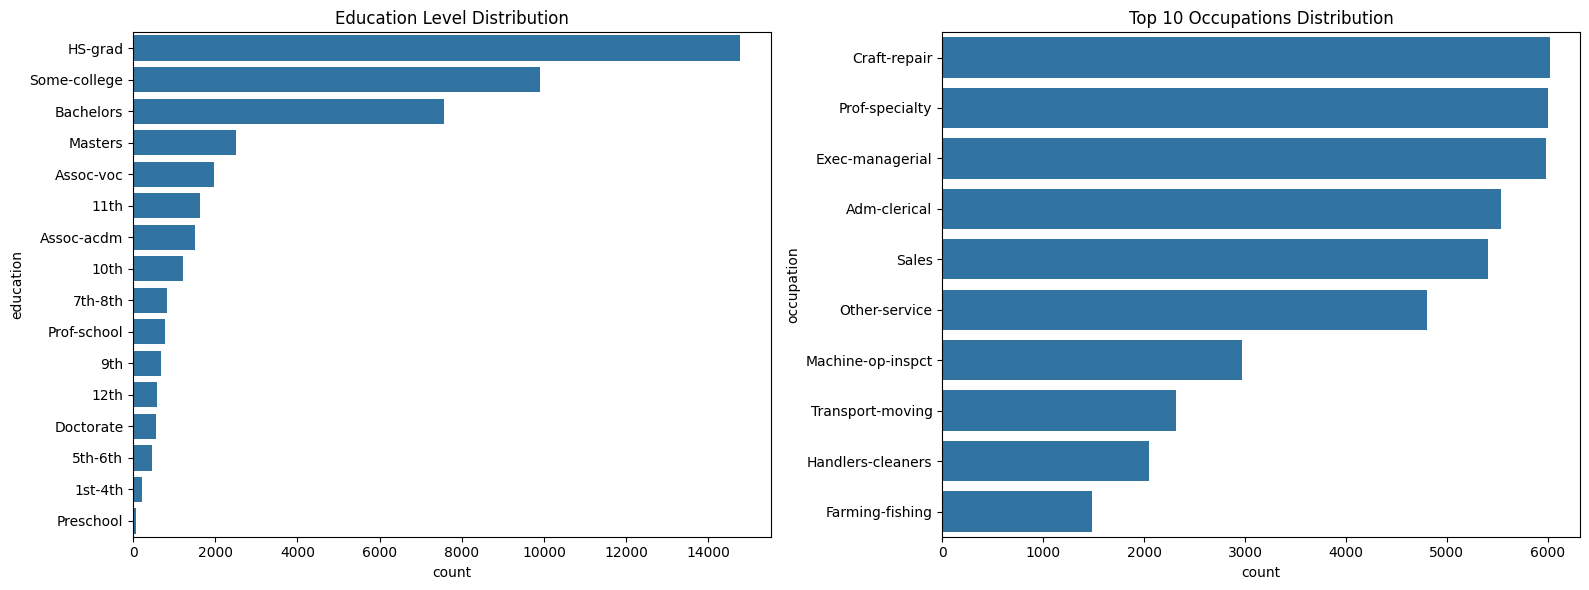


--- Training Logistic Regression Model ---
Model training complete.
Accuracy for Logistic Regression: 0.8496
Confusion Matrix:
[[6377  465]
 [ 895 1308]]
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      6842
           1       0.74      0.59      0.66      2203

    accuracy                           0.85      9045
   macro avg       0.81      0.76      0.78      9045
weighted avg       0.84      0.85      0.84      9045


--- Training K-Nearest Neighbors Model ---
Model training complete.
Accuracy for K-Nearest Neighbors: 0.8314
Confusion Matrix:
[[6200  642]
 [ 883 1320]]
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.91      0.89      6842
           1       0.67      0.60      0.63      2203

    accuracy                           0.83      9045
   macro avg       0.77      0.75      0.76      9045
weighted avg       0.83      0.83      0.83  

In [ ]:
# Employee Salary Predictions using adult.csv

# This notebook outlines the steps taken to build and compare multiple machine learning models
# that predict whether an individual earns more or less than $50,000 annually.

# 1. Load Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

# 2. Load the Dataset
# We'll load the data and handle missing values, represented by '?'.
try:
    data = pd.read_csv("adult 3.csv", na_values='?')
    print("Data loaded successfully.")
except FileNotFoundError:
    print("Error: adult 3.csv not found. Please make sure it's in the same directory.")
    exit()

# 3. Initial Data Inspection and Cleaning
# Let's get a summary of the dataset and clean it by dropping missing values.
print("Dataset Info:")
data.info()
print("\nMissing values (count):")
print(data.isnull().sum())

data.dropna(inplace=True)
print(f"\nShape of data after dropping missing values: {data.shape}")

# 4. Exploratory Data Analysis (EDA)
# Let's visualize the distribution of our target variable 'income'.
plt.figure(figsize=(8, 6))
sns.countplot(x='income', data=data)
plt.title('Income Distribution')
plt.show()

# Visualize some key features
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.countplot(y='education', data=data, order=data['education'].value_counts().index, ax=axes[0])
axes[0].set_title('Education Level Distribution')
sns.countplot(y='occupation', data=data, order=data['occupation'].value_counts().head(10).index, ax=axes[1])
axes[1].set_title('Top 10 Occupations Distribution')
plt.tight_layout()
plt.show()

# 5. Data Preprocessing
# We'll prepare the data for our machine learning models.
# Define features (X) and target (y).
X = data.drop(['income', 'fnlwgt', 'educational-num'], axis=1)
y = data['income'].apply(lambda x: 1 if x == '>50K' else 0)

# Separate numerical and categorical columns
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# Create preprocessing pipelines for both numerical and categorical data.
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Use ColumnTransformer to apply the correct transformations to the columns.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Split the data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Model Training and Comparison
# We'll train and evaluate multiple models to find the best performer.
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Support Vector Classifier (SVC)': SVC(kernel='rbf', random_state=42),
    'Random Forest Classifier': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting Classifier': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n--- Training {name} Model ---")
    
    # Create a full pipeline for the current model
    full_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Train the pipeline
    full_pipeline.fit(X_train, y_train)
    print("Model training complete.")
    
    # Predict and evaluate
    y_pred = full_pipeline.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    
    print(f"Accuracy for {name}: {accuracy:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

# 7. Final Comparison and Conclusion
print("\n--- Final Model Comparison ---")
best_model_name = max(results, key=results.get)

for name, accuracy in results.items():
    print(f"{name} Accuracy: {accuracy:.4f}")

print(f"\nConclusion: The '{best_model_name}' model performed the best with an accuracy of {results[best_model_name]:.4f}.")

# 8. Save the best performing model pipeline
# We will save the best model pipeline for the Streamlit app to use
best_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', models[best_model_name])
])
best_pipeline.fit(X, y) # Train the final pipeline on the full dataset

try:
    joblib.dump(best_pipeline, 'best_model.pkl')
    print(f"\nBest model pipeline ('{best_model_name}') saved to 'best_model.pkl'.")
except Exception as e:
    print(f"\nError saving the best model: {e}")